In [1]:
!hostnamectl

 Static hostname: gpub033.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 7160fa58ed57460fad63c00d1f2ce1bc
         Boot ID: dd46862237b04cc8bbdb0f652b978f04
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: A48


In [ ]:
# # Check JAX sees the GPU
# import jax
# print(jax.devices())  # should show CudaDevice(id=0)
# print(jax.default_backend())  # should show 'gpu'

# # Check CUDA version
# import subprocess
# print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

# # Check JAX/jaxlib versions
# import jaxlib
# print(f"JAX version: {jax.__version__}")
# print(f"jaxlib version: {jaxlib.__version__}")

# # Quick GPU computation test
# import jax.numpy as jnp
# x = jnp.ones((1000, 1000))
# print(f"Array device: {x.devices()}")  # should show CudaDevice

In [2]:
# tmp 
import os
tmp_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=8"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Cache compiled kernels to disk (create this directory first)
cache_dir = os.path.join(tmp_dir, "asachan_jax_cache")
os.makedirs(cache_dir, exist_ok=True)
os.environ["JAX_COMPILATION_CACHE_DIR"] = cache_dir

In [3]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [4]:
import os
os.chdir("/projects/bgdb/asachan/methods/OT_FM")  # adjust path if needed
from utils import *

In [5]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [13]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/All_Cell_Types.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad'

In [34]:
rna_adata = sc.read_h5ad(rna_path_filtered)
rna_adata

AnnData object with n_obs × n_vars = 172396 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

In [35]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['MuSC', 'Type II', 'Type I', 'Specialized MF'])].copy()

In [36]:
rna_adata.obs['age_sex'] = (
    rna_adata.obs['age'].astype('float').astype(int).astype(str)
    + '_' + 
    rna_adata.obs['Sex'].astype(str)
)
rna_adata.obs['age_sex'].value_counts().sort_index()

age_sex
15_Male      17422
17_Female      561
18_Male       4943
29_Female     2157
34_Female     4551
34_Male      13663
38_Male       3810
45_Male      10643
77_Male        657
79_Female     2855
79_Male        617
80_Female    16981
82_Female      865
82_Male       9111
84_Female     3939
84_Male       3235
85_Male       1890
88_Male       1299
89_Female     5058
92_Female     6939
99_Female     1207
Name: count, dtype: int64

# MuSC to type1/2 transitions

In [37]:
# Define interval mappings
interval_map = {
    # Male intervals
    '15_Male': 'interval_1_M',
    '18_Male': 'interval_1_M',
    '34_Male': 'interval_2_M',
    '38_Male': 'interval_2_M',
    '45_Male': 'interval_2_M',
    # Female intervals
    '17_Female': 'interval_1_F',
    '29_Female': 'interval_1_F',
    '34_Female': 'interval_2_F',
}

rna_adata.obs['intervals_young'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

# Verify
rna_adata.obs['intervals_young'].value_counts()

intervals_young
interval_2_M    28116
interval_1_M    22365
interval_2_F     4551
interval_1_F     2718
Name: count, dtype: int64

In [38]:
mask = (
    # interval_1: MuSC only
    (rna_adata.obs['intervals_young'].isin(['interval_1_M', 'interval_1_F']) & 
     (rna_adata.obs['Annotation'] == 'MuSC'))
    |
    # interval_2: Type II, Type I, Specialized MF only (no MuSC)
    (rna_adata.obs['intervals_young'].isin(['interval_2_M', 'interval_2_F']) & 
     rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'Specialized MF']))
)

rna_adata = rna_adata[mask].copy()

# Verify — should show no MuSC in interval_2 and no other types in interval_1
rna_adata.obs.groupby(['intervals_young', 'Annotation']).size()

intervals_young  Annotation    
interval_1_F     MuSC               1902
interval_1_M     MuSC               1591
interval_2_F     Specialized MF      367
                 Type I             1782
                 Type II            2376
interval_2_M     Specialized MF     3317
                 Type I            11628
                 Type II           12799
dtype: int64

In [42]:
n_cells_downsample = 2000
adatas = []

for interval, idx in rna_adata.obs.groupby('intervals_young').groups.items():
    subset = rna_adata[idx].copy()
    
    if interval.startswith('interval_2') and subset.shape[0] > n_cells_downsample:
        sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
    
    adatas.append(subset)

rna_adata = ad.concat(adatas)
del adatas

print(rna_adata.obs['intervals_young'].value_counts())

intervals_young
interval_2_F    2000
interval_2_M    2000
interval_1_F    1902
interval_1_M    1591
Name: count, dtype: int64


In [ ]:
# subset adata to male and female cells based on intervals_young
rna_adata_male = rna_adata[rna_adata.obs['intervals_young'].isin(['interval_1_M', 'interval_2_M'])].copy()
rna_adata_female = rna_adata[rna_adata.obs['intervals_young'].isin(['interval_1_F', 'interval_2_F'])].copy()

In [45]:
rna_adata_female.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_young
CELL214_N1_1_1_1_2_1_10_1,P26_1,1867.000000,612,P26,1.071237,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
CELL893_N1_1_1_1_2_1_10_1,P26_1,1161.000000,592,P26,3.014643,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
CELL847_N1_1_1_1_2_1_10_1,P26_1,1189.000000,655,P26,1.850294,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
CELL803_N1_1_1_1_2_1_10_1,P26_1,1265.000000,670,P26,0.632411,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
CELL1445_N1_2_1_1_2_1_10_1,P26_2,1909.000000,619,P26,0.366684,17.0,snRNA,Female,Spain,young_pop,MuSC,17_Female,interval_1_F
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL2848_N1_2_1_11_1,YM2_2,3378.779154,1326,YM2,0.156017,34.0,snRNA,Female,China,young_pop,Type II,34_Female,interval_2_F
CELL1318_N1_1_1_11_1,YM2_1,4901.285016,1650,YM2,0.008360,34.0,snRNA,Female,China,young_pop,Type I,34_Female,interval_2_F
CELL699_N1_2_1_11_1,YM2_2,4769.162345,1661,YM2,0.546587,34.0,snRNA,Female,China,young_pop,Type II,34_Female,interval_2_F
CELL949_N1_2_1_11_1,YM2_2,4380.935736,1608,YM2,0.057779,34.0,snRNA,Female,China,young_pop,Type II,34_Female,interval_2_F


In [46]:

import anndata as ad
ad.settings.allow_write_nullable_strings = True
# save
rna_adata_male.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_young_male.h5ad')
rna_adata_female.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_young_female.h5ad')

## subset to young and old transitions (separately)

In [ ]:
#young_adata = rna_adata[rna_adata.obs['sample'] == 'YM3'].copy()
#old_adata = rna_adata[rna_adata.obs['sample'] == 'YM2'].copy()


In [ ]:
# subset to samples of interest
#rna_adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

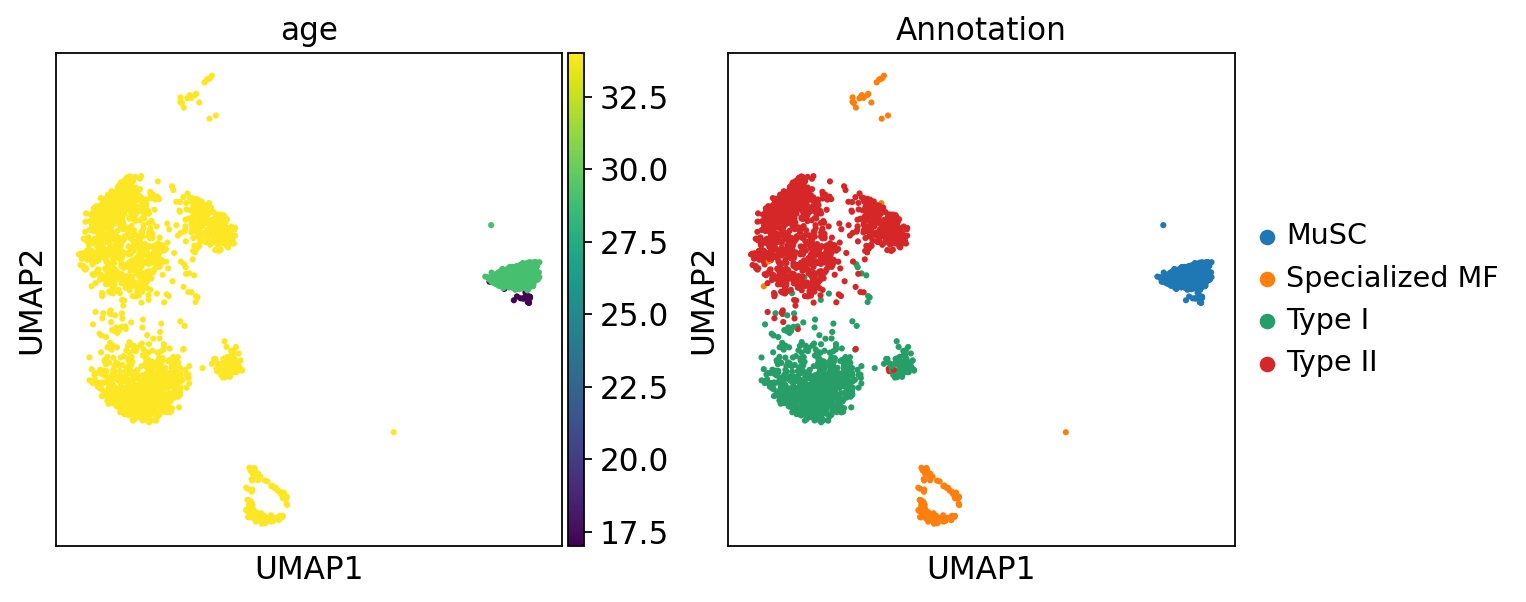

In [47]:
sc.pl.umap(rna_adata_female, color=['age', 'Annotation'])

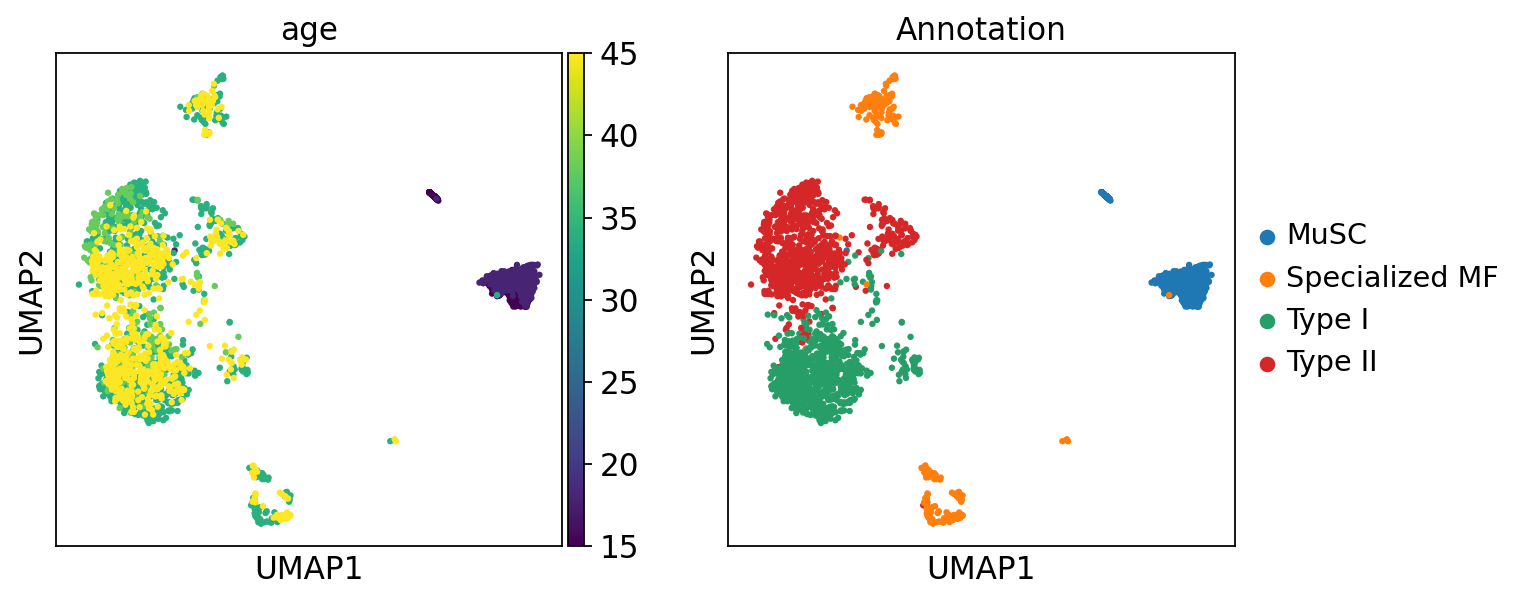

In [48]:
sc.pl.umap(rna_adata_male, color=['age', 'Annotation'])

In [ ]:
adata = rna_adata_female

In [77]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'MuSC', 'Specialized MF'])].copy()
#rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II'])].copy()

#### Lower bound on number of cells per age

In [ ]:
# age_counts = rna_adata.obs['age'].value_counts()
# valid_ages = age_counts[age_counts >= 500].index

# rna_adata = rna_adata[rna_adata.obs['age'].isin(valid_ages)].copy()

# # # Verify
# print(rna_adata.obs['age'].value_counts())

age
15.0    14109
34.0    11579
45.0     6264
18.0     4331
29.0     3095
38.0     1967
Name: count, dtype: int64


#### Upper bound on number of cells per age

In [ ]:
# n_cells_downsample = 5000
# adatas = []

# for age, idx in rna_adata.obs.groupby('age').groups.items():
#     subset = rna_adata[idx].copy()
#     if subset.shape[0] > n_cells_downsample:
#         sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
#     adatas.append(subset)

# rna_adata = ad.concat(adatas)
# del adatas

# # Verify
# print(rna_adata.obs['age'].value_counts())

age
15.0    5000
34.0    5000
45.0    5000
18.0    4331
29.0    3095
38.0    1967
Name: count, dtype: int64


In [55]:
rna_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation
CELL2642_N1_2_2_3_1,YM3_2,2524.697283,886,YM3,0.060426,34.0,snRNA,Male,China,young_pop,Type II
CELL3760_N1_2_2_3_1,YM3_2,1977.744396,1014,YM3,0.000000,34.0,snRNA,Male,China,young_pop,Type I
CELL3769_N1_1_2_3_1,YM3_1,3783.243098,1494,YM3,0.028564,34.0,snRNA,Male,China,young_pop,Type II
CELL3816_N1_2_3_1,YM3_3,2765.552665,1099,YM3,0.039776,34.0,snRNA,Male,China,young_pop,Type II
CELL705_N2_1_1_3_1,YM3_1,5674.888465,1541,YM3,0.098634,34.0,snRNA,Male,China,young_pop,Type II
...,...,...,...,...,...,...,...,...,...,...,...
CELL137_N2_2_1_3_1,YM3_2,4455.424608,1497,YM3,0.039018,34.0,snRNA,Male,China,young_pop,Type II
CELL4391_N1_2_3_1,YM3_3,2633.865708,998,YM3,0.053470,34.0,snRNA,Male,China,young_pop,Type I
CELL3699_N1_1_2_3_1,YM3_1,4003.580682,1352,YM3,0.051135,34.0,snRNA,Male,China,young_pop,Type I
CELL2000_N1_2_3_1,YM3_3,3743.819981,1370,YM3,0.015975,34.0,snRNA,Male,China,young_pop,Type II


In [ ]:
# #load adata with sub cluster labels
# type2_sub_cluster = sc.read_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/Myofiber_scsn_RNA.h5ad')
# type2_sub_cluster

AnnData object with n_obs × n_vars = 150894 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII'
    var: 'features'
    uns: 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors', 'integrated_snn_res.3_colors', 'integrated_snn_res.7_colors', 'rank_genes_groups'
    obsm: 'X_umap'

In [ ]:
# type2_sub_cluster.obs['Annotation'].value_counts()

Annotation
Type I         65605
Type II        49814
ENOX1+ (II)     9963
ID1+ (I)        6569
TNNT2+ (I)      4601
DCLK1+ (I)      4576
ID1+ (II)       3035
MTJ             2676
SAA2+ (II)      2368
DCLK1+ (II)      708
SAA2+ (I)        630
NMJ              264
TNNT2+ (II)       85
Name: count, dtype: int64

In [ ]:
# subset_adata = type2_sub_cluster[type2_sub_cluster.obs['Annotation'].isin(['Type II', 'ENOX1+ (II)', 'ID1+ (II)', 'SAA2+ (II)', 'DCLK1+ (II)', 'TNNT2+ (II)'])]

In [ ]:
# # save 
#rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/type2_samples_oi.h5ad')

In [56]:
display(rna_adata.obs['Annotation'].value_counts())
print(rna_adata.obs["Annotation"].unique())

Annotation
Type II           6257
Type I            5312
Specialized MF    1872
MuSC               222
Name: count, dtype: int64

['Type II', 'Type I', 'Specialized MF', 'MuSC']
Categories (4, str): ['MuSC', 'Specialized MF', 'Type I', 'Type II']


In [81]:
# make temporal info numeric
def adapt_time(x):
    if x["Annotation"] in ["MuSC"]:
        return 1.5
    if x["Annotation"] in ["Type II", "Type I", "Specialized MF"]:
        return 3.5
    raise ValueError
rna_adata.obs["Annotation"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

ValueError: 

In [58]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="Annotation")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [59]:
import networkx as nx

batch_column = "Annotation"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

In [60]:
#if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
n_components = nx.number_connected_components(G)
print(f"Number of connected components: {n_components}")
# Check sizes of each component
sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"Component sizes: {sizes}")

Number of connected components: 1
Component sizes: [13663]


In [61]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

In [62]:
t1, t2 = 1.5, 3.5
prob = tp0[t1, t2]
expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)
Gdf = df.loc[expected, expected].astype(float)
prob.set_graph_xy(Gdf, t=100.0)

In [63]:
import scanpy as sc
sc.settings.verbosity = 3  # shows more detail
# epsilon: entropic regularization strength
#batch_size is for sinkhorn iterations, the grpah omputation and transfer to gpu (compilation) takes most time
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7, batch_size=5000) 

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(222, 13441)].                                  


W0313 13:09:28.711714  914714 gemm_fusion_autotuner.cc:1162] Slow kernel for %gemm_fusion_dot_general.1_computation (parameter_0: f32[13663,13663], parameter_1: f32[13663,13663]) -> f32[13663,13663] {
  %parameter_0 = f32[13663,13663]{1,0} parameter(0)
  %parameter_1 = f32[13663,13663]{1,0} parameter(1)
  ROOT %dot_general.0 = f32[13663,13663]{1,0} dot(%parameter_0, %parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, metadata={op_name="jit(matmul)/dot_general" source_file="/tmp/ipykernel_914714/73918518.py" source_line=5 source_end_line=5 source_column=6 source_end_column=85}
} took: 2.289030029s. {block_m:16,block_n:16,block_k:64,split_k:1,num_stages:4,num_warps:2,num_ctas:1,is_tma_allowed:0}
W0313 13:09:34.135632  914714 gemm_fusion_autotuner.cc:1162] Slow kernel for %gemm_fusion_dot_general.1_computation (parameter_0: f32[13663,13663], parameter_1: f32[13663,13663]) -> f32[13663,13663] {
  %parameter_0 = f32[13663,13663]{1,0} parameter(0)
  %parameter_1 = f32[13663,13

### Save objects after computation

In [64]:
import cloudpickle
with open(f'{tmp_dir}/tp0_YM3_Musc_type2_1.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

Saved!


In [65]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5_soi.npz"), T_15_35_csr)

## Visualize cell clusters of interest

In [14]:
import cloudpickle
# load pickle
with open(f'{tmp_dir}/tp0_5k_type2.pkl', 'rb') as f:
    tp0 = cloudpickle.load(f)

In [78]:
rna_adata.obs["Annotation"] = rna_adata.obs["Annotation"].astype("category")
order_cell_types = rna_adata.obs["Annotation"].cat.categories.tolist()
order_cell_types

['MuSC', 'Specialized MF', 'Type I', 'Type II']

In [79]:
#aggregating the transport matrix by bins of interest
# ANSCESTORS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_large",
)
plt.tight_layout()
plt.show()

ValueError: None of `['MuSC', 'Specialized MF', 'Type I', 'Type II']`, found in the source annotations.

In [ ]:
#aggregating the transport matrix by chronological age
# DESCENDANTS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=True,
    key_added="transitions_1.5_3.5_soi",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_soi",
)
plt.tight_layout()
plt.show()

In [ ]:
tp0.pull(source=1.5, target=3.5, data="Annotation")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[1.5],
    basis="X_umap",
    ax=axes[0],
    title=["Myofibers at time 1.5 (young_pop)"],
)

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[1],
    title=["Myofibers at time 3.5 (old_pop)"],
)

fig.subplots_adjust(wspace=0.3)

In [ ]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"Annotation": order_cell_types},
    target_groups={"Annotation": order_cell_types},
    threshold=0.05,
    order_annotations=order_cell_types[::-1],
    normalize=True,
)

In [ ]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

## Identifying driver genes

In [ ]:
X_orig = tp0.adata.X.copy()

#check mean and min and max of X
print(X_orig.mean(), X_orig.min(), X_orig.max())

In [ ]:
sc.pp.normalize_total(tp0.adata)
sc.pp.log1p(tp0.adata)

In [ ]:
# Get driver TFs for age-chronological_young/cell-cluster-2 (young) → age-chronological_old/cell-cluster-1 (old) transition
drivers_spec_mf_type2, top_pos, top_neg = driver_tfs_for_subset(
    tp=tp0,
    old_cell_cluster='Type II',
    young_cell_cluster='Specialized MF',
    cell_cluster_col='Annotation',
    t_young=1.5,
    t_old=3.5,
)